In [44]:
# here we are implementing conditional workflow of LangGraph by creating a review replying agent 
# the agent will reply on the basis of sentiments of user - ie. positive or negative

In [45]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [46]:
load_dotenv()

True

In [47]:
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [48]:
# schema for sentiments
class SentimentSchema(BaseModel):
    sentiments: Literal["positive","negative","neutral"] = Field(description="sentiments of the review")

# schema for diagnosis
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [49]:
structured_model_for_sentiments = model.with_structured_output(SentimentSchema)
structured_model_for_diagnosis = model.with_structured_output(DiagnosisSchema)

In [50]:
prompt = "What is the sentiment of the following review - This product is very good but some features are missing"

output = structured_model_for_sentiments.invoke(prompt)

output.sentiments

'neutral'

In [51]:
# creating state
class ReviewState(TypedDict):

    review: str
    sentiments: Literal["positive","negative","neutral"]
    diagnosis: dict | None
    response: str

In [52]:
# node for finding sentiments..
def identify_sentiments(state: ReviewState):

    prompt = f"Indentify sentiments of following Review: \n\n{state['review']}"
    output = structured_model_for_sentiments.invoke(prompt)

    return {"sentiments":output.sentiments}

In [53]:
# conditioning...

def check_sentiments(state: ReviewState) -> Literal["positive_response", "neutral_response", "run_diagnosis"]:
    if state["sentiments"] == "positive":
        return "positive_response"
    elif state["sentiments"] == "neutral":
        return "neutral_response"
    else:
        return "run_diagnosis"

In [54]:
# posivite sentiments node

def positive_response(state: ReviewState):

    prompt = f"""
Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website.
"""
    response = model.invoke(prompt).content

    return {"response":response}

In [55]:
# neutral sentiment node

def neutral_response(state: ReviewState):

    prompt = f"""
Write a polite and professional response to this review:
\n\n"{state['review']}"\n
Thank the user for their feedback, acknowledge their comments, and let them know that their suggestions will help us improve.
"""
    response = model.invoke(prompt).content

    return {"response":response}

In [56]:
# negative sentiments node

# 1. diagnosis
def run_diagnosis(state:ReviewState):

    prompt = f"""
Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""    

    diagnosis = structured_model_for_diagnosis.invoke(prompt)

    return {"diagnosis":diagnosis.model_dump()}

# 2. response
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""
You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {"response":response}

In [57]:
# create a graph
graph = StateGraph(ReviewState)

# create nodes
graph.add_node("identify_sentiments", identify_sentiments)
graph.add_node("positive_response",positive_response)
graph.add_node("neutral_response",neutral_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

# create edges
graph.add_edge(START, "identify_sentiments")

graph.add_conditional_edges("identify_sentiments", check_sentiments)

graph.add_edge("positive_response", END)

graph.add_edge("neutral_response", END)

graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response", END)

# compile graph
workflow = graph.compile()

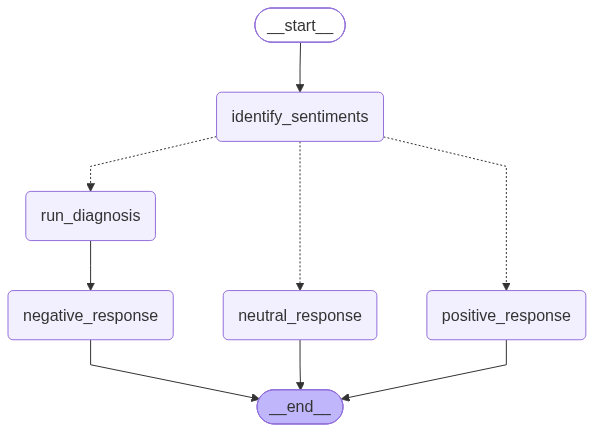

In [58]:
workflow

In [64]:
# execute graph

initial_state = {
    "review":"This app has been extremely frustrating to use. It crashes every time I try to upload a file, and customer support hasn't responded in days. This issue is affecting my work and needs to be fixed immediately."
}

workflow.invoke(initial_state)

{'review': "This app has been extremely frustrating to use. It crashes every time I try to upload a file, and customer support hasn't responded in days. This issue is affecting my work and needs to be fixed immediately.",
 'sentiments': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a frustrating bug issue. I can imagine how annoying that must be for you, and I'm here to help resolve it as quickly as possible.\n\nI've reviewed your report, and I appreciate you marking the urgency as high. I'm going to do my best to provide a prompt and effective solution. Can you please provide me with more details about the issue, such as any error messages you're seeing or the steps you took leading up to the problem? This will help me better understand the situation and work towards a resolution.\n\nIn the meantime, I want to assure you that I'm committed to resolving this issue as soon as possible